### Demoblatt - LuS
--- 



# `K-Nearest Neighbors`


**``K-Nearest Neighbors``** ist eine **Supervised Learning Methode**. Dabei erfolgt die Klassifikation eines Datenpunktes auf Grund der **``K``** nächsten Nachbarn.<br>

> <br>
> Voraussetzung für die Verwendung ist, das die Zielvariable `kategorisch` ist.<br>
> <br>
>

Es ist besonders nützlich für Aufgaben wie Mustererkennung, Bilderkennung oder Vorhersagen.

Grundidee:

 - Wähle eine Anzahl von Nachbarn (K).
 - Finde die K nächsten Datenpunkte (Nachbarn) zu einem neuen, noch nicht klassifizierten Datenpunkt.
 - Der neue Punkt wird der Klasse zugeordnet, die bei den K Nachbarn am häufigsten vorkommt.

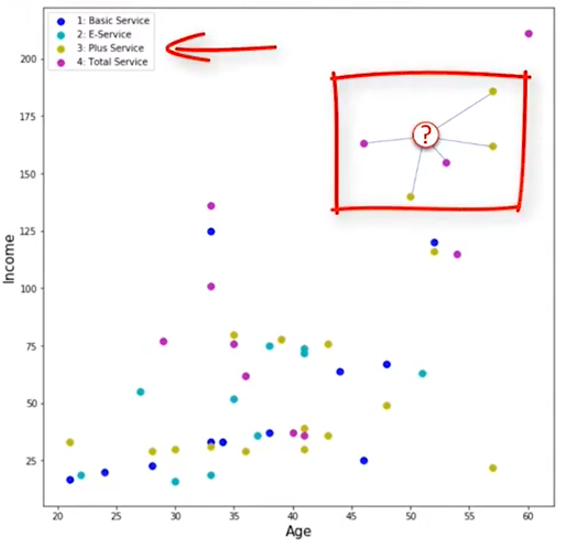


Im Fall der Entscheidung auf Grund der 5 nächsten Nachbarn (**``k=5``**), erhält man für den Stern eine Klassifizierung des Datenpunktes als **Plus Service**.  

Das Modell muss also nicht nur darauf trainiert werden auf Grund einer bestimmten Anzahl eine Klassifizierung vorzunehmen, sondern man muss auch prüfen, welche Anzahl an nächsten Nachbarn das beste Ergebnis liefert.


<div style="background-color:rgba(250, 250, 0, 0.1)">

---

# Aufgabe: 

Aus der ``Sepal-Länge`` und der ``Sepal-Breite`` einer Iris soll die ``Art`` vorausgesagt werden.  

---



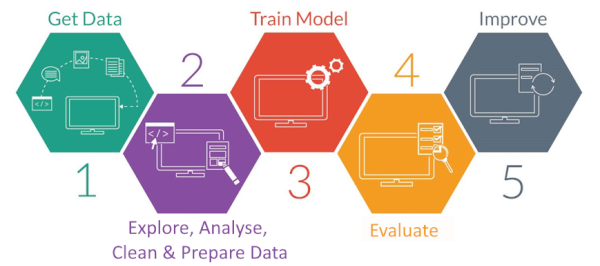

---
# ``Schritt 1:`` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_iris` verwendet.

In [ ]:
from sklearn import datasets
import pandas as pd

#-------------------------------------------------------------------------
# Laden der Daten
dfIris, target = datasets.load_iris( return_X_y=True, as_frame=True )

dfIris['speciesname'] = target.replace({0:'setosa',1:'versicolor', 2:'virginica'})

dfIris.head()

### Untersuchen der Kategorie
Da die vorherzusagende Variable **``kategorisch``** ist, muß geprüft werden, ob genügend Beobachtungen in jeder Kategorie vorhanden sind. Ermittle deshalb die Anzahl der Beobachtungen in jeder Kategorie des Features, welches vorhergesagt werden soll.


In [ ]:
print(dfIris['speciesname'].value_counts())


### Untersuchen wie die Kategorien verteilt sind.  

``Beachte:`` Das Modell kNN versucht auf Grund der k nächsten Nachbarn die Kategorie einer Beobachtung festzulegen.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#------------------------------------------------------------
plt.figure(figsize=(6, 4))

#------------------------------------------------------------
# Trainingsdaten ausgeben
sns.scatterplot(data=dfIris, x='sepal length (cm)', y='sepal width (cm)', hue='speciesname', palette='Set1')


<div style="background-color:rgba(250, 0, 0, 0.1)">

---
**``ÜBERLEGE:`` Welche Kategorie wird einer Iris mit einer Sepal-Länge von 5.9 cm und Sepal-Breite von 2.9 cm zugeordnet, wenn die 3 nächsten Nachbarn (k=3) untersucht werden?**<br>  
 
Füge hier deine Antwort ein




---
</div>

---
# ``Schritt 2:`` Data Preprocessing


### Daten auswählen

Erstellen eines Dataframes mit den Fetures, welche für die Vorhersage verwendet werden sollen und eines für das Feature, welches vorhergesagt werden soll.


In [ ]:
#------------------------------------------------------------
# Features auswählen
cols_x  = ['sepal length (cm)','sepal width (cm)']  # independent
cols_y  = 'speciesname'                             # dependent: Vorhersagen

#------------------------------------------------------------
dfLearn_X = dfIris[cols_x]
dfLearn_Y = dfIris[cols_y]

### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
testsize = 0.3
dfTrain_x, dfTest_x, dfTrain_y, dfTest_y = train_test_split( dfLearn_X, dfLearn_Y,
                test_size= testsize, 
                random_state=0)

#------------------------------------------------------------
# Dataframe in Array umrechnens
train_x = dfTrain_x.values       # independent
train_y = dfTrain_y.values       # dependent

test_x  = dfTest_x.values        # independent
test_y  = dfTest_y.values        # dependent
#------------------------------------------------------------

---
# ``Schritt 3:`` Modell erstellen und trainieren



### Modell erstellen und trainieren


Für das Modell verwenden wir diesmal **``KNeighborsClassifier``** aus dem **Sciki-Learn Paket**.  

> <br>
> Für dieses Modell ist die Anzahl der Nachbarn, welche untersucht werden sollen, entscheidend.<br>  
> <br>
>


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

#------------------------------------------------------------
# Modell erstellen und trainieren
k = 2  # nächsten Nachbarn festlegen

model = KNeighborsClassifier(n_neighbors = k)
model.fit(train_x, train_y)

### Vorhersagen erstellen
Erstelle mit dem trainierten Modell nun für die Trainings- und Testdaten die jeweiligen Vorhersagen.


In [ ]:
#------------------------------------------------------------
# Vorhersagen für die Trainingsdaten erstellen
pred_train_y = model.predict(train_x)

#------------------------------------------------------------
# Vorhersagen für die Testdaten erstellen
pred_y = model.predict(test_x)

Visueller Vergleich der tatsächlichen und der vorhergesagten Werte

In [ ]:
# Vergleiche die ersten 5 Werte der Testdaten mit den vorhergesagten Werten
print("Testdaten: ")
print ("Tatsächlich: ", test_y [0:5])
print ("Vorhersagen: ", pred_y [0:5])

---
# ``Schritt 4:`` Evaluieren


## Genauigkeit des Modells

Die Genauigkeit der Vorhersage kann mittels eines **``accuracy_score``** ermittelt werden.

In [ ]:
# Prüfen der Genauigkeit des Models
from sklearn import metrics

print("Genauigkeit der Trainingsdaten:  %.3f " %  metrics.accuracy_score(train_y, pred_train_y))
print("Genauigkeit der Testdaten:       %.3f " %  metrics.accuracy_score(test_y, pred_y))


<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Was kannst du über die Genauigkeit des Modells sagen?<br>
 Begründe deine Antwort!**<br>  
 
89% der Trainingsdaten werden korrekt vorhergesagt. Allerdings nur 75% der Testdaten.

Das kann auf ein Overfitting hindeuten und deshalb sollte das Modell noch weiter untersucht werden.

---
</div>

## Visualisieren der Entscheidungsgrenzen


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.inspection import DecisionBoundaryDisplay
%matplotlib inline

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

#------------------------------------------------------------
# Entscheidungsgrenzen des Modells visualisieren
axs[0].set_title('Trainings-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator( 
            model, train_x, xlabel='sepal length (cm)',ylabel='sepal width (cm)', 
            alpha=0.5, eps=0.5, ax=axs[0], cmap = 'brg')

axs[1].set_title('Test-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator(
            model, test_x, xlabel='sepal length (cm)',ylabel='sepal width (cm)', 
            alpha=0.5, eps=0.5, ax=axs[1], cmap = 'brg')

#------------------------------------------------------------
# Tatsächliche Werte anzeigen
sns.scatterplot(x=train_x[:,0], y=train_x[:,1], hue=train_y, palette= ['b','r','g'],  ax=axs[0], hue_order=model.classes_)
sns.scatterplot(x=test_x [:,0], y=test_x [:,1], hue=test_y,  palette= ['b','r','g'],  ax=axs[1], hue_order=model.classes_)

plt.show()

---

## Praxistest



In [ ]:
# Testdaten generieren
sepallength = 5.9
sepalwidth  = 2.9
test_data = [[sepallength, sepalwidth]]

# Vorhersage erstellen
species = model.predict(test_data)

# Species ausgeben
print("Vorhersage der Iris-Art: ", species[0])


Nun stellt sich noch die Frage, wie hoch ist die Wahrscheinlichkeit das die Vorhersage richtig ist.  
Dazu kann mit ``predict_proba``, die Wahrscheinlichkeit für jede einzelne Kategorie ermittelt werden.

In [ ]:
prob = model.predict_proba( test_data )

print("Wahrscheinlichkeit: ", prob)

for art in range(0, prob.shape[1] ):
    proz = prob[0,art]*100
    name = model.classes_[art]
    print('%-12s' % name, '%5.1f %%' % proz )

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Vergleiche das Ergebnis mit dem zugehörigen Wert aus den Beobachtungen.<br>
Und erläutere weiters wie wahrscheinlich das Ergebnis ist.**<br>  
 
Die Vorhersage wird mit 100% zur Gattung der Virginica gezählt. Alle anderen Arten sind ausgeschlossen.

``Das Ergebnis ist somit eine sehr sichere Vorhersage.``

---
</div>

---
# ``Schritt 5:`` Improve



### ELLBOW-Methode: ``Finden der besten Genauigkeit``


Da sich die Genauigkeit mit der Anzahl verändert, ist es wichtig das beste **``k``** (Anzahl der nächsten Nachbarn) zu bestimmen. Dazu wird die Genauigkeit aller **``k's``** in einem bestimmten Bereich ermittelt und das beste Ergebnis gesucht.

In [ ]:
import numpy as np

training_accuracy = []
test_accuracy = []

# Bereich von k festlegen
test_range = range(1, 10)

for k in test_range:
    
    # Model trainieren 
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(train_x,train_y)

    # Trainingsgenauigkeit bestimmen
    pred  = model.predict(train_x)
    score = metrics.accuracy_score(train_y, pred)
    training_accuracy.append(score)

    # Testgenauigkeit bestimmen
    pred  = model.predict(test_x)
    score = metrics.accuracy_score(test_y, pred)
    test_accuracy.append(score)

best_k = test_range[ np.argmax(test_accuracy) ]
best_score = max(test_accuracy)

# Ausgabe aller Scores 
print( "Höchste TEST-Genauigkeit ist %.3f" % best_score, "mit k=", best_k) 

#### Verlauf der Genauigkeit
Damit wir die Scores der verschiedenen **``k's``** besser vergleichen können, geben wir sie als Graph aus.

In [ ]:
plt.plot(test_range, training_accuracy, label="Trainings-Genauigkeit")
plt.plot(test_range, test_accuracy, label="Test-Genauigkeit")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
#plt.savefig('knn_compare_model')

plt.show()